In [1]:
!pip install datasets sacrebleu matplotlib numpy torch torch-summary torchvision torchaudio torchinfo -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.9 MB/s eta 0:00:00


In [2]:
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from datasets import load_dataset
import unicodedata
from datasets import load_dataset
from tokenizers import Tokenizer, normalizers
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import Lowercase, NFC
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Dataset
import math
from tqdm import tqdm
from sacrebleu import corpus_bleu
from torchinfo import summary


os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
PAD_IDX = 0
BOS_IDX = 1
EOS_IDX = 2

class DataPreprocessor:
    def __init__(self, dataset_name, num_train, num_valid, test_split, vocab_size):
        self.dataset_name = dataset_name
        self.num_train = num_train
        self.num_valid = num_valid
        self.test_split = test_split
        self.vocab_size = vocab_size
        self.en_tokenizer = None
        self.vi_tokenizer = None
        self.train_data = None
        self.valid_data = None
        self.test_data = None
        
    def load_data(self):
        full_train = load_dataset(self.dataset_name, split='train').shuffle(seed=42)
        self.train_data = full_train.select(range(self.num_train))
        self.valid_data = full_train.select(range(self.num_train, self.num_train + self.num_valid))
        self.test_data = load_dataset(self.dataset_name, split=self.test_split)
        
    def build_tokenizers(self):
        en_corpus = [ex['translation']['en'].lower() for ex in tqdm(self.train_data, desc="EN Corpus")]
        vi_corpus = [unicodedata.normalize('NFC', ex['translation']['vi'].lower()) for ex in tqdm(self.train_data, desc="VI Corpus")]
        
        special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]

        self.en_tokenizer = Tokenizer(BPE(unk_token="<unk>"))
        self.en_tokenizer.normalizer = normalizers.Sequence([Lowercase(), NFC()])
        self.en_tokenizer.pre_tokenizer = Whitespace()
        en_trainer = BpeTrainer(
            special_tokens=special_tokens, 
            vocab_size=self.vocab_size,
            min_frequency=2
        )
        self.en_tokenizer.train_from_iterator(en_corpus, en_trainer)
        
        self.vi_tokenizer = Tokenizer(BPE(unk_token="<unk>"))
        self.vi_tokenizer.normalizer = normalizers.Sequence([Lowercase(), NFC()])
        self.vi_tokenizer.pre_tokenizer = Whitespace()
        vi_trainer = BpeTrainer(
            special_tokens=special_tokens, 
            vocab_size=self.vocab_size,
            min_frequency=2
        )
        self.vi_tokenizer.train_from_iterator(vi_corpus, vi_trainer)
        
    def get_vocab_sizes(self):
        return self.en_tokenizer.get_vocab_size(), self.vi_tokenizer.get_vocab_size()
    
    def prepare(self):
        self.load_data()
        self.build_tokenizers()
        return self

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout_p = dropout
        
    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        output = F.scaled_dot_product_attention(
            Q, K, V, 
            attn_mask=mask, 
            dropout_p=self.dropout_p if self.training else 0.0,
            is_causal=False
        )
        
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(output)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, 
                 num_encoder_layers, num_decoder_layers, d_ff, dropout, pad_idx):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx
        
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_encoder_layers)
        ])
        
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_decoder_layers)
        ])
        
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
        
    def create_masks(self, src, tgt):
        src_mask = (src != self.pad_idx).unsqueeze(1).unsqueeze(2)
        
        tgt_pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)
        tgt_len = tgt.size(1)
        look_ahead_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        tgt_mask = tgt_pad_mask & look_ahead_mask
        
        return src_mask, tgt_mask
    
    def forward(self, src, tgt):
        src_mask, tgt_mask = self.create_masks(src, tgt)
        
        src_emb = self.dropout(self.pos_encoding(self.src_embedding(src) * math.sqrt(self.d_model)))
        tgt_emb = self.dropout(self.pos_encoding(self.tgt_embedding(tgt) * math.sqrt(self.d_model)))
        
        enc_output = src_emb
        for layer in self.encoder_layers:
            enc_output = layer(enc_output, src_mask)
        
        dec_output = tgt_emb
        for layer in self.decoder_layers:
            dec_output = layer(dec_output, enc_output, src_mask, tgt_mask)
        
        return self.fc_out(dec_output)

class TranslationDataset(Dataset):
    def __init__(self, data, en_tokenizer, vi_tokenizer, max_len):
        self.data = data
        self.en_tokenizer = en_tokenizer
        self.vi_tokenizer = vi_tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        en_text = self.data[idx]['translation']['en']
        vi_text = self.data[idx]['translation']['vi']
        
        en_tokens = self.en_tokenizer.encode(en_text).ids
        vi_tokens = self.vi_tokenizer.encode(vi_text).ids
        
        en_tokens = [BOS_IDX] + en_tokens[:self.max_len-2] + [EOS_IDX]
        vi_tokens = [BOS_IDX] + vi_tokens[:self.max_len-2] + [EOS_IDX]
        
        return torch.tensor(en_tokens), torch.tensor(vi_tokens)

def collate_fn(batch):
    en_batch, vi_batch = zip(*batch)
    en_lens = [len(x) for x in en_batch]
    vi_lens = [len(x) for x in vi_batch]
    
    en_padded = torch.nn.utils.rnn.pad_sequence(en_batch, batch_first=True, padding_value=PAD_IDX)
    vi_padded = torch.nn.utils.rnn.pad_sequence(vi_batch, batch_first=True, padding_value=PAD_IDX)
    
    return en_padded, vi_padded

In [5]:
preprocessor = DataPreprocessor(
    dataset_name="Angelectronic/IWSLT15_English_Vietnamese",
    num_train=70000,
    num_valid=5000,
    test_split="test",
    vocab_size=16000
)
preprocessor.prepare()

README.md:   0%|          | 0.00/538 [00:00<?, ?B/s]

data/train-00000-of-00001-32a2d2de769100(…):   0%|          | 0.00/18.4M [00:00<?, ?B/s]

data/test-00000-of-00001-90850d7d3fd0398(…):   0%|          | 0.00/188k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/133166 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1268 [00:00<?, ? examples/s]

VI Corpus: 100%|██████████| 70000/70000 [00:04<00:00, 14839.88it/s]


In [6]:
hyperparameters = {
    'd_model': 256,          
    'num_heads': 1,
    'num_encoder_layers': 3, 
    'num_decoder_layers': 3,  
    'd_ff': 1024,            
    'dropout': 0.1,
    'max_len': 128,            
    'batch_size': 32,         
    'learning_rate': 0.0005,  
    'num_epochs': 15         
}

In [7]:
train_dataset = TranslationDataset(preprocessor.train_data, preprocessor.en_tokenizer, 
                                   preprocessor.vi_tokenizer, hyperparameters['max_len'])
valid_dataset_obj = TranslationDataset(preprocessor.valid_data, preprocessor.en_tokenizer, 
                                       preprocessor.vi_tokenizer, hyperparameters['max_len'])

train_loader = DataLoader(train_dataset, batch_size=hyperparameters['batch_size'], 
                         shuffle=True, collate_fn=collate_fn, num_workers=4)
valid_loader = DataLoader(valid_dataset_obj, batch_size=hyperparameters['batch_size'], 
                         shuffle=False, collate_fn=collate_fn)

src_vocab_size, tgt_vocab_size = preprocessor.get_vocab_sizes()

In [8]:
model = Transformer(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=hyperparameters['d_model'],
    num_heads=hyperparameters['num_heads'],
    num_encoder_layers=hyperparameters['num_encoder_layers'],
    num_decoder_layers=hyperparameters['num_decoder_layers'],
    d_ff=hyperparameters['d_ff'],
    dropout=hyperparameters['dropout'],
    pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=hyperparameters['learning_rate'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [9]:
batch_size = hyperparameters['batch_size']
max_len = hyperparameters['max_len']
summary(model, 
        input_data=[
            torch.zeros((batch_size, max_len), dtype=torch.long).to(device), 
            torch.zeros((batch_size, max_len), dtype=torch.long).to(device)
        ],
        col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
Transformer                              [32, 128]                 [32, 128, 12137]          --                        True
├─Embedding: 1-1                         [32, 128]                 [32, 128, 256]            4,096,000                 True
├─PositionalEncoding: 1-2                [32, 128, 256]            [32, 128, 256]            --                        --
├─Dropout: 1-3                           [32, 128, 256]            [32, 128, 256]            --                        --
├─Embedding: 1-4                         [32, 128]                 [32, 128, 256]            3,107,072                 True
├─PositionalEncoding: 1-5                [32, 128, 256]            [32, 128, 256]            --                        --
├─Dropout: 1-6                           [32, 128, 256]            [32, 128, 256]            --                        --
├─ModuleLis

In [10]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    progress_bar = tqdm(loader, desc='Training', leave=False)
    
    for src, tgt in progress_bar:
        src, tgt = src.to(device), tgt.to(device)
        
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        
        optimizer.zero_grad()
        output = model(src, tgt_input)
        
        loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    progress_bar = tqdm(loader, desc='Validating', leave=False)
    
    with torch.no_grad():
        for src, tgt in progress_bar:
            src, tgt = src.to(device), tgt.to(device)
            
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            
            output = model(src, tgt_input)
            loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)

print("Training model...")
train_losses = []
valid_losses = []

for epoch in range(hyperparameters['num_epochs']):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    valid_loss = evaluate(model, valid_loader, criterion)
    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    
    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch+1}/{hyperparameters["num_epochs"]}, '
      f'Train Loss: {train_loss:.4f}, '
      f'Valid Loss: {valid_loss:.4f}, '
      f'LR: {current_lr:.6f}')

Training model...


Epoch 1/15, Train Loss: 5.2865, Valid Loss: 4.8083, LR: 0.000500


Epoch 2/15, Train Loss: 4.6916, Valid Loss: 4.5379, LR: 0.000500


Epoch 3/15, Train Loss: 4.4650, Valid Loss: 4.3974, LR: 0.000500


Epoch 4/15, Train Loss: 4.3199, Valid Loss: 4.3101, LR: 0.000500


...

Epoch 11/15, Train Loss: 3.8842, Valid Loss: 4.0649, LR: 0.000500


Epoch 12/15, Train Loss: 3.8515, Valid Loss: 4.0471, LR: 0.000500


Epoch 13/15, Train Loss: 3.8212, Valid Loss: 4.0376, LR: 0.000500


Epoch 14/15, Train Loss: 3.7960, Valid Loss: 4.0340, LR: 0.000500


Epoch 15/15, Train Loss: 3.7718, Valid Loss: 4.0250, LR: 0.000500


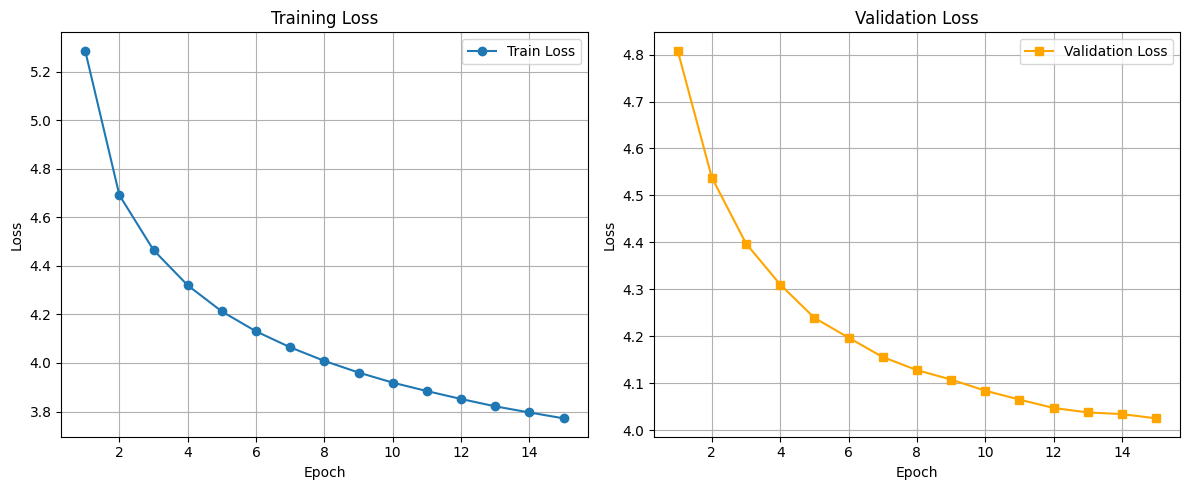

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, hyperparameters['num_epochs']+1), train_losses, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, hyperparameters['num_epochs']+1), valid_losses, marker='s', label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
def translate(model, sentence, en_tokenizer, vi_tokenizer, max_len=128, option="greedy", beam_size=5, no_repeat_ngram_size=3):
    model.eval()
    
    sentence = sentence.lower()
    tokens = en_tokenizer.encode(sentence).ids
    tokens = [BOS_IDX] + tokens + [EOS_IDX]
    src = torch.tensor(tokens).unsqueeze(0).to(device)

    if option == "greedy":
        tgt_tokens = [BOS_IDX]
        for _ in range(max_len):
            tgt = torch.tensor(tgt_tokens).unsqueeze(0).to(device)
            with torch.no_grad():
                output = model(src, tgt)
            
            logits = output[0, -1]
            
            if no_repeat_ngram_size > 0 and len(tgt_tokens) >= no_repeat_ngram_size:
                cur_ngram = tgt_tokens[-(no_repeat_ngram_size-1):]
                for i in range(len(tgt_tokens) - no_repeat_ngram_size + 1):
                    if tgt_tokens[i:i+no_repeat_ngram_size-1] == cur_ngram:
                        forbidden_token = tgt_tokens[i + no_repeat_ngram_size - 1]
                        logits[forbidden_token] = float('-inf')
            
            next_token = logits.argmax().item()
            tgt_tokens.append(next_token)
            if next_token == EOS_IDX:
                break
        return vi_tokenizer.decode(tgt_tokens[1:-1])

    elif option == "beam":
        # (score, tokens)
        beams = [(0, [BOS_IDX])]
        
        for _ in range(max_len):
            new_beams = []
            for score, tgt_tokens in beams:
                if tgt_tokens[-1] == EOS_IDX:
                    new_beams.append((score, tgt_tokens))
                    continue
                
                tgt = torch.tensor(tgt_tokens).unsqueeze(0).to(device)
                with torch.no_grad():
                    output = model(src, tgt)
                
                logits = output[0, -1]
                probs = torch.log_softmax(logits, dim=-1)
                
                if no_repeat_ngram_size > 0 and len(tgt_tokens) >= no_repeat_ngram_size:
                    cur_ngram = tgt_tokens[-(no_repeat_ngram_size-1):]
                    for i in range(len(tgt_tokens) - no_repeat_ngram_size + 1):
                        if tgt_tokens[i:i+no_repeat_ngram_size-1] == cur_ngram:
                            forbidden_token = tgt_tokens[i + no_repeat_ngram_size - 1]
                            probs[forbidden_token] = float('-inf')

                top_probs, top_indices = torch.topk(probs, beam_size)
                for i in range(beam_size):
                    new_beams.append((score + top_probs[i].item(), tgt_tokens + [top_indices[i].item()]))
            
            def score_fn(beam):
                s, t = beam
                return s / (len(t)**0.7) 

            beams = sorted(new_beams, key=score_fn, reverse=True)[:beam_size]
            
            if all(t[-1] == EOS_IDX for s, t in beams):
                break
                
        return vi_tokenizer.decode(beams[0][1][1:-1])

def calculate_bleu(model, test_data, en_tokenizer, vi_tokenizer, num_samples=None, option="greedy"):
    model.eval()
    references = []
    hypotheses = []
    
    if num_samples is None:
        num_samples = len(test_data)
    
    for i in tqdm(range(num_samples), desc=f'Calculating BLEU ({option})'):
        src_text = test_data[i]['translation']['en']
        ref_text = test_data[i]['translation']['vi']
        
        hyp_text = translate(model, src_text, en_tokenizer, vi_tokenizer, option=option)
        
        references.append([ref_text])
        hypotheses.append(hyp_text)
    
    score = corpus_bleu(hypotheses, references).score
    return score

In [13]:
def visualize_attention(model, sentence, en_tokenizer, vi_tokenizer, layer_idx=0, head_idx=0):
    model.eval()
    
    sentence = sentence.lower()
    tokens = en_tokenizer.encode(sentence).ids
    tokens = [BOS_IDX] + tokens + [EOS_IDX]
    src = torch.tensor(tokens).unsqueeze(0).to(device)
    
    src_mask, _ = model.create_masks(src, src)
    
    with torch.no_grad():
        src_emb = model.dropout(model.pos_encoding(model.src_embedding(src) * math.sqrt(model.d_model)))
        enc_output = src_emb
        enc_attention_weights = []
        
        for layer in model.encoder_layers:
            Q = layer.self_attn.W_q(enc_output)
            K = layer.self_attn.W_k(enc_output)
            b, n, d = Q.shape
            h = layer.self_attn.num_heads
            d_k = d // h
            
            Q = Q.view(b, n, h, d_k).transpose(1, 2)
            K = K.view(b, n, h, d_k).transpose(1, 2)
            
            scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
            if src_mask is not None:
                scores = scores.masked_fill(src_mask == False, float('-inf'))
            attn = torch.softmax(scores, dim=-1)
            enc_attention_weights.append(attn)
            
            enc_output = layer(enc_output, src_mask)

        tgt_tokens = [BOS_IDX]
        for _ in range(50):
            tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(device)
            output = model(src, tgt_tensor)
            next_token = output[0, -1].argmax().item()
            tgt_tokens.append(next_token)
            if next_token == EOS_IDX: break

        tgt_final = torch.tensor(tgt_tokens).unsqueeze(0).to(device)
        _, tgt_mask = model.create_masks(src, tgt_final)
        tgt_emb = model.dropout(model.pos_encoding(model.tgt_embedding(tgt_final) * math.sqrt(model.d_model)))
        
        dec_output = tgt_emb
        cross_attention_weights = []
        
        for layer in model.decoder_layers:

            x = layer.norm1(dec_output + layer.dropout(layer.self_attn(dec_output, dec_output, dec_output, tgt_mask)))
            
            Q_c = layer.cross_attn.W_q(x)
            K_c = layer.cross_attn.W_k(enc_output)
            b, n_q, d = Q_c.shape
            n_k = K_c.size(1)
            h = layer.cross_attn.num_heads
            d_k = d // h
            
            Q_c = Q_c.view(b, n_q, h, d_k).transpose(1, 2)
            K_c = K_c.view(b, n_k, h, d_k).transpose(1, 2)
            
            scores_c = torch.matmul(Q_c, K_c.transpose(-2, -1)) / math.sqrt(d_k)
            if src_mask is not None:
                scores_c = scores_c.masked_fill(src_mask == False, float('-inf'))
            attn_c = torch.softmax(scores_c, dim=-1)
            cross_attention_weights.append(attn_c)
            
            dec_output = layer(dec_output, enc_output, src_mask, tgt_mask)

    src_labels = [en_tokenizer.id_to_token(i) for i in tokens]
    tgt_labels = [vi_tokenizer.id_to_token(i) for i in tgt_tokens]
    
    attn_weights_enc = enc_attention_weights[layer_idx][0, head_idx].cpu().numpy()
    attn_weights_cross = cross_attention_weights[layer_idx][0, head_idx].cpu().numpy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    im1 = ax1.imshow(attn_weights_enc, cmap='viridis')
    ax1.set_xticks(range(len(src_labels))); ax1.set_yticks(range(len(src_labels)))
    ax1.set_xticklabels(src_labels, rotation=45); ax1.set_yticklabels(src_labels)
    ax1.set_title(f'Encoder Self-Attention (L{layer_idx}, H{head_idx})')
    
    im2 = ax2.imshow(attn_weights_cross, cmap='viridis')
    ax2.set_xticks(range(len(src_labels))); ax2.set_yticks(range(len(tgt_labels)))
    ax2.set_xticklabels(src_labels, rotation=45); ax2.set_yticklabels(tgt_labels)
    ax2.set_title(f'Decoder Cross-Attention (L{layer_idx}, H{head_idx})')
    
    plt.colorbar(im1, ax=ax1); plt.colorbar(im2, ax=ax2)
    plt.tight_layout()
    plt.show()
    
    return vi_tokenizer.decode(tgt_tokens[1:-1])

In [14]:
test_sentences = [
    "I have a dream.",
    "This is my story.",
    "I love my work.",
    "It is very simple.",
    "We can change the world.",
    "Thank you very much."
]

for i, sentence in enumerate(test_sentences, 1):
    hyp_greedy = translate(model, sentence, preprocessor.en_tokenizer, preprocessor.vi_tokenizer, option="greedy")
    hyp_beam = translate(model, sentence, preprocessor.en_tokenizer, preprocessor.vi_tokenizer, option="beam", beam_size=2)
    
    print(f"\n{i}. English: {sentence}")
    print(f"   Greedy : {hyp_greedy}")
    print(f"   Beam   : {hyp_beam}")


1. English: I have a dream.
   Greedy : tôi có một giấc mơ .
   Beam   : tôi có một giấc mơ .

2. English: This is my story.
   Greedy : đây là câu chuyện của tôi .
   Beam   : đây là câu chuyện của tôi .

3. English: I love my work.
   Greedy : tôi thích làm việc .
   Beam   : tôi yêu công việc của mình .

4. English: It is very simple.
   Greedy : nó rất đơn giản .
   Beam   : nó rất đơn giản .

5. English: We can change the world.
   Greedy : chúng ta có thể thay đổi thế giới .
   Beam   : chúng ta có thể thay đổi thế giới .

6. English: Thank you very much.
   Greedy : cảm ơn các bạn rất nhiều .
   Beam   : cảm ơn các bạn rất nhiều .


In [15]:
bleu_greedy = calculate_bleu(model, preprocessor.test_data, preprocessor.en_tokenizer, 
                             preprocessor.vi_tokenizer, num_samples=200, option="greedy")
print(f"Final BLEU Score (Greedy): {bleu_greedy:.2f}")

bleu_beam = calculate_bleu(model, preprocessor.test_data, preprocessor.en_tokenizer, 
                           preprocessor.vi_tokenizer, num_samples=200, option="beam")
print(f"Final BLEU Score (Beam): {bleu_beam:.2f}")

Calculating BLEU (greedy): 100%|██████████| 200/200 [00:23<00:00,  8.56it/s]


Final BLEU Score (Greedy): 18.26


Calculating BLEU (beam): 100%|██████████| 200/200 [01:54<00:00,  1.74it/s]

Final BLEU Score (Beam): 19.30



Visualizing Attention for Example 1: 'I have a dream.'


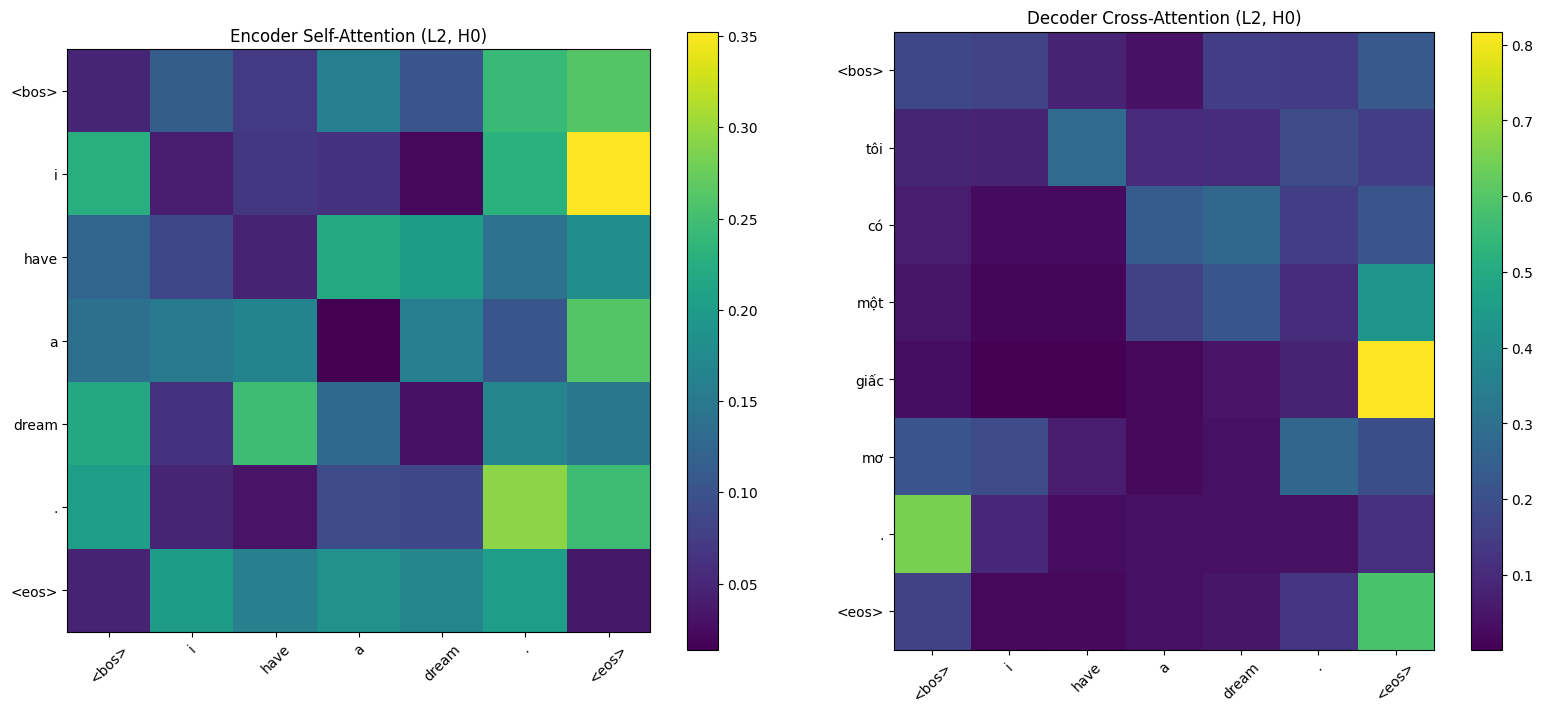


Visualizing Attention for Example 2: 'This is my story.'


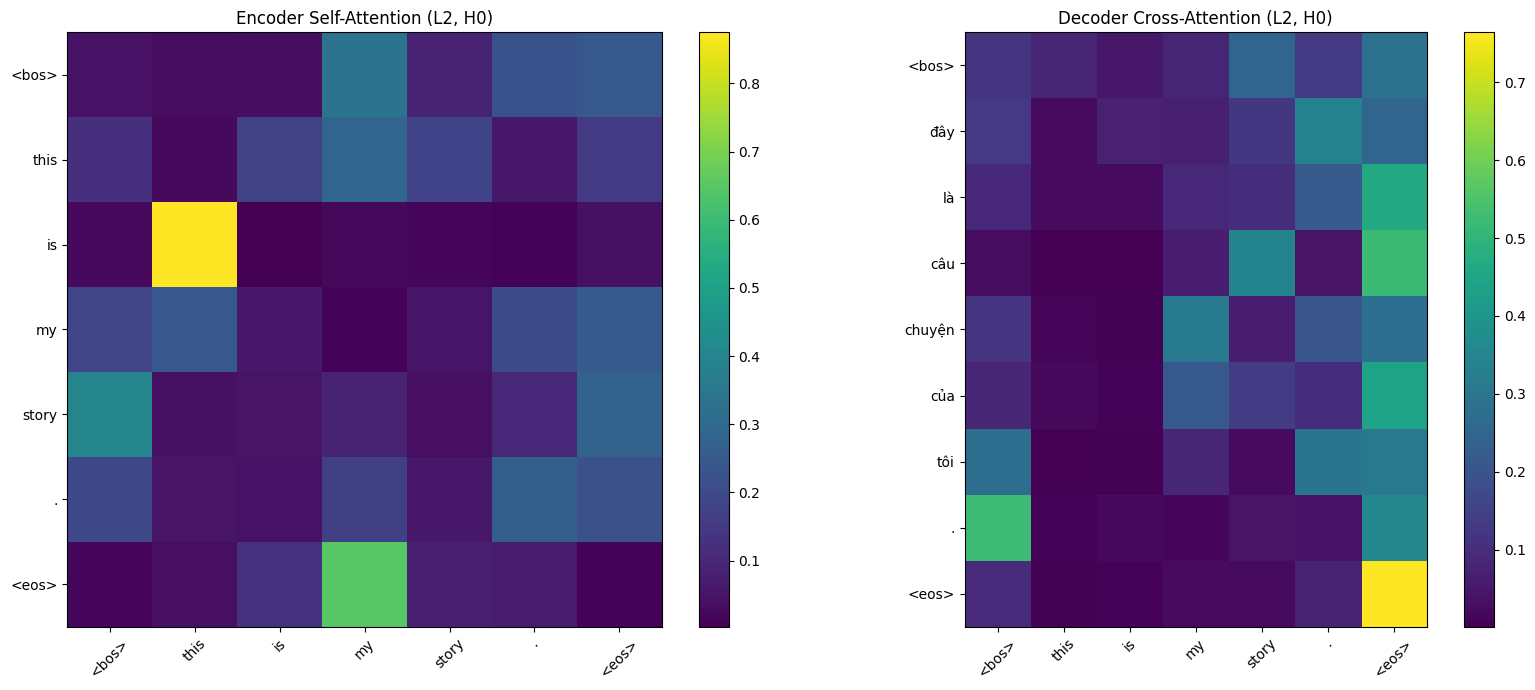


Visualizing Attention for Example 3: 'I love my work.'


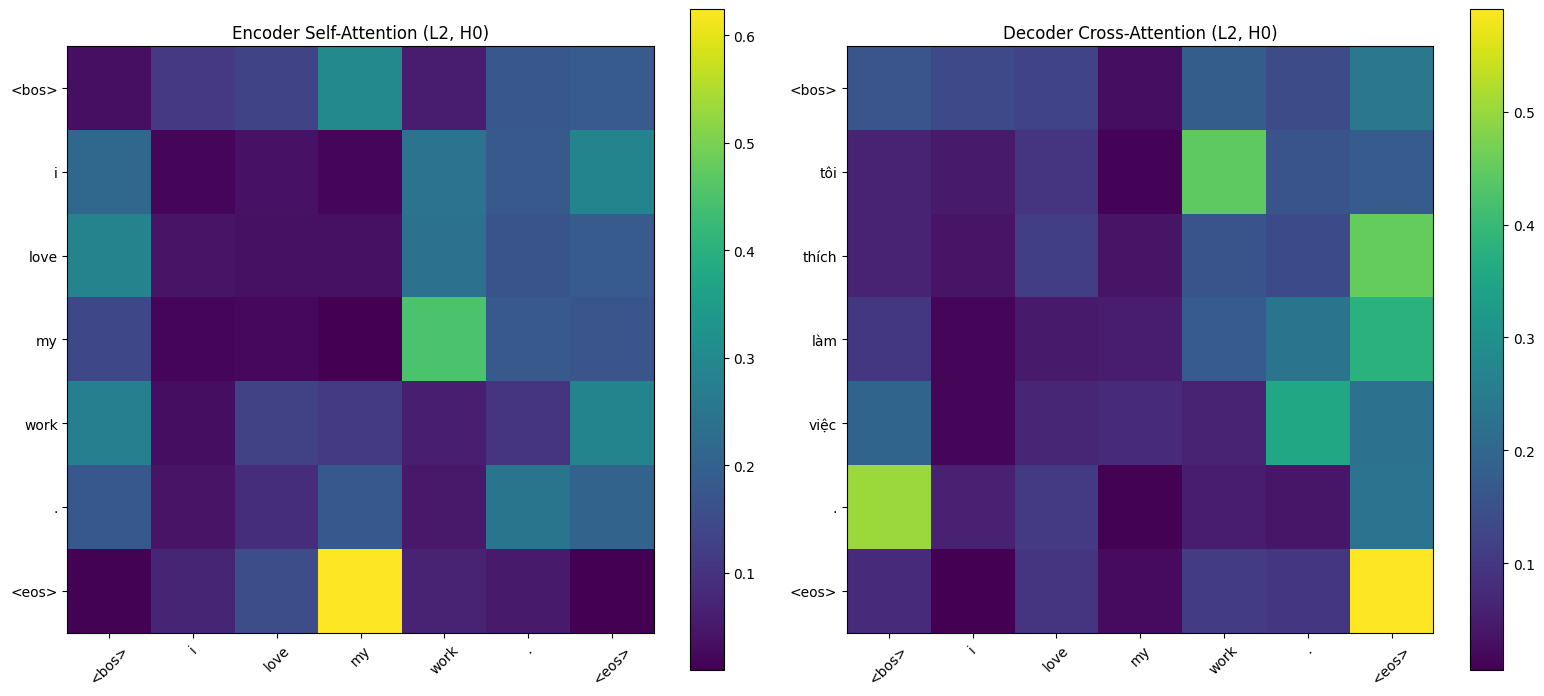


Visualizing Attention for Example 4: 'It is very simple.'


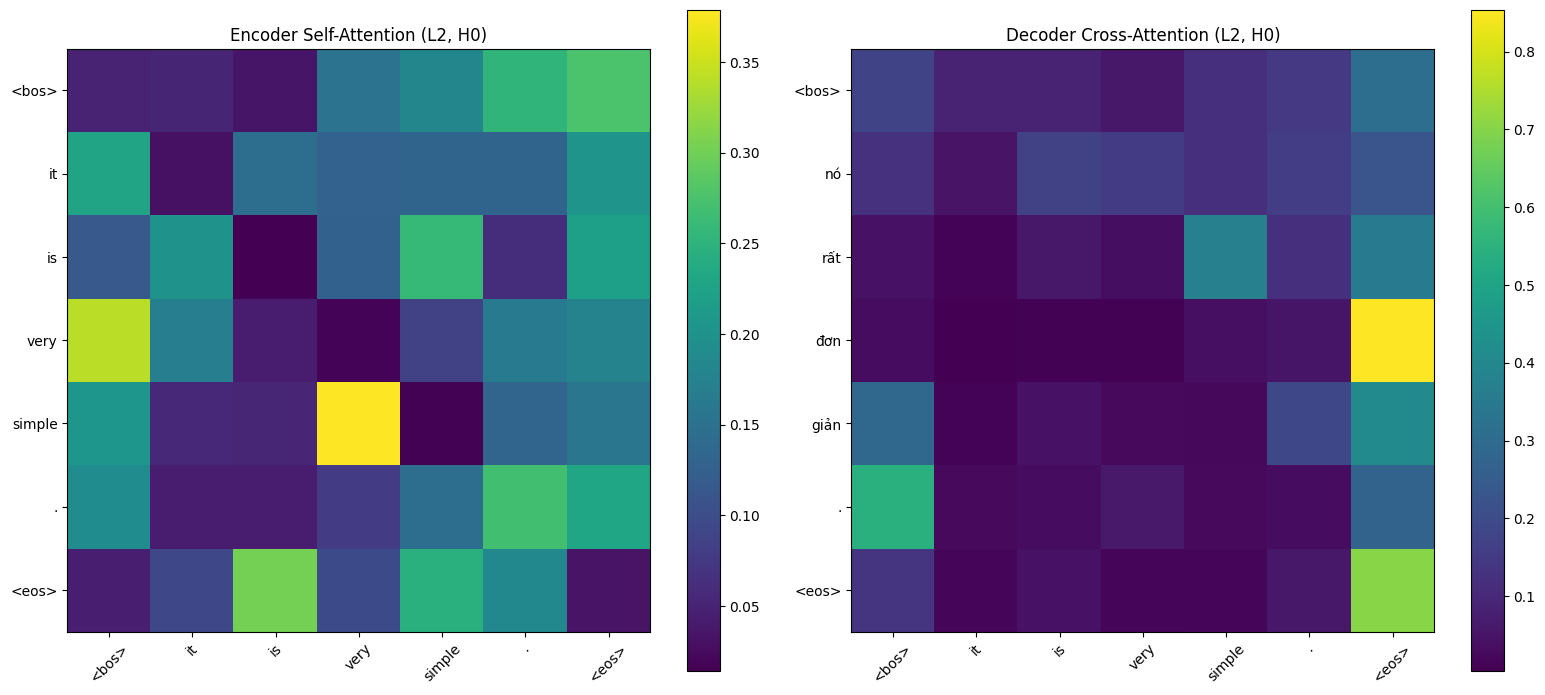


Visualizing Attention for Example 5: 'We can change the world.'


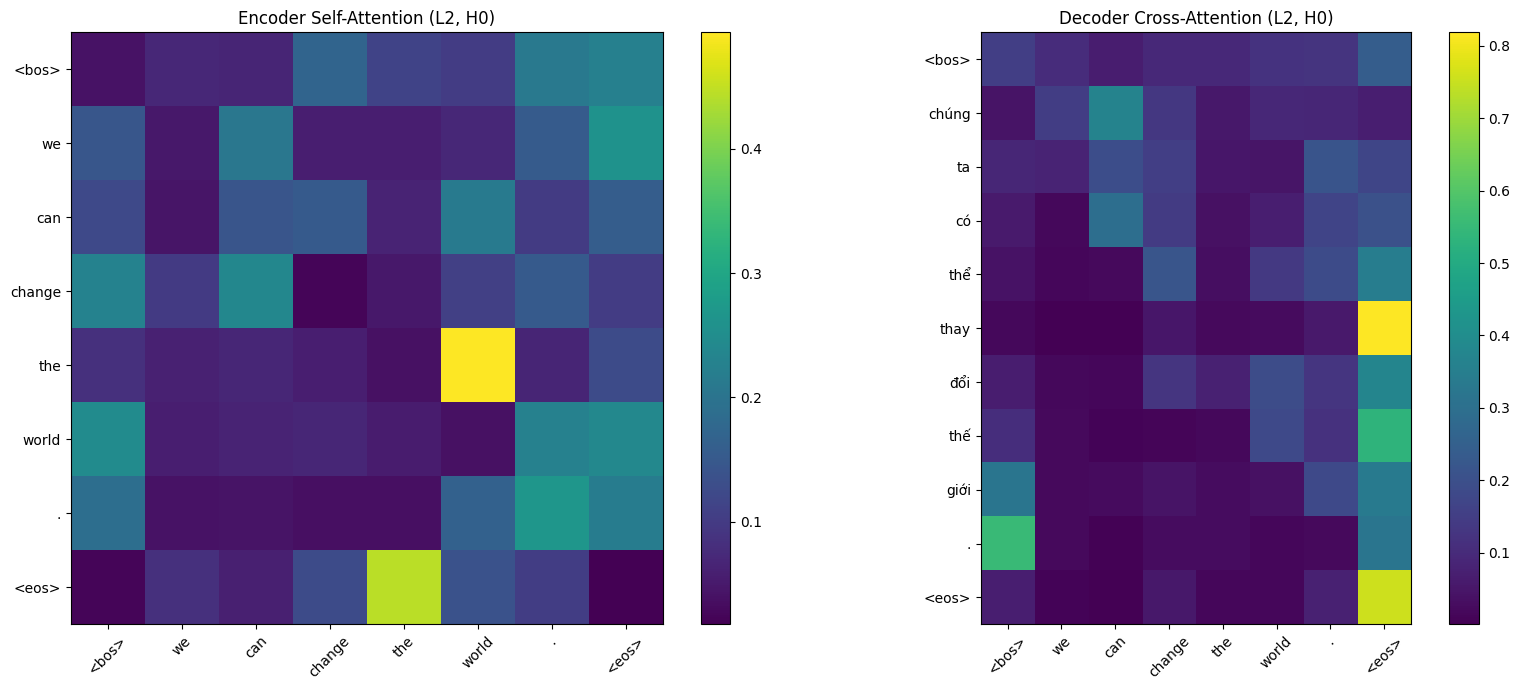


Visualizing Attention for Example 6: 'Thank you very much.'


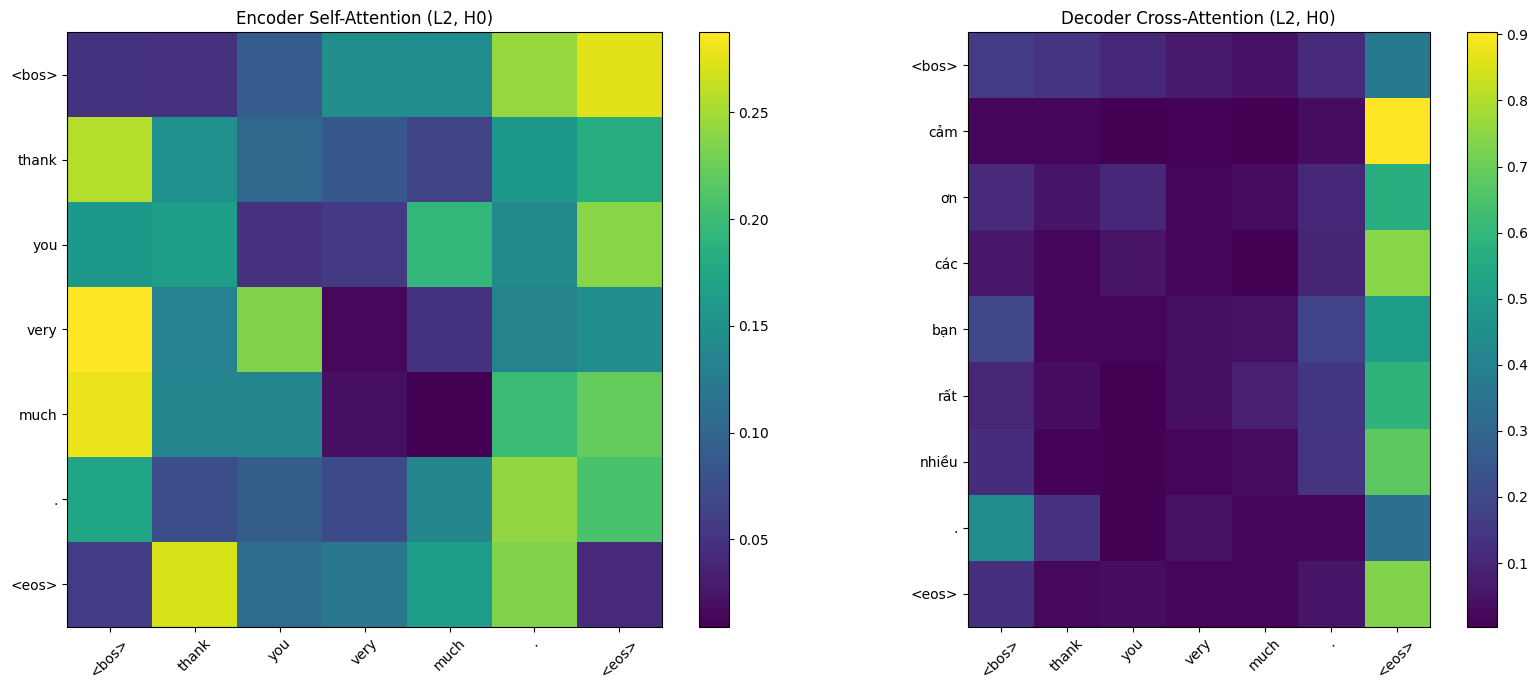

In [16]:
for i, sentence in enumerate(test_sentences, 1):
    print(f"\nVisualizing Attention for Example {i}: '{sentence}'")
    visualize_attention(model, sentence, preprocessor.en_tokenizer, preprocessor.vi_tokenizer, layer_idx=2, head_idx=0)